In [1]:
# Libraries and modules
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, f1_score, matthews_corrcoef, auc, precision_recall_curve, roc_curve, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import VarianceThreshold, SelectKBest, RFE, RFECV, SelectFromModel
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn import tree

In [2]:
# Step 1: Read the original data files
MoGCN_all_omic = pd.read_csv("combined_MOGCN_data.csv", index_col=0)

# Check the dimensions of the dataframes
print("MoGCN_all_omic shape:", MoGCN_all_omic.shape)

MoGCN_all_omic shape: (960, 301)


In [3]:
MoGCN_all_omic.head()

,C3orf72,AMAC1L3,BSND,FOXL2,ID2B,SFTPB,WNT3A,PPIAL4C,KRT13,OR10AD1,...,cg04469303,cg16928795,cg00954566,cg17952262,cg24476569,cg11953868,cg09215553,cg07550362,cg15827031,Subtype
Sample.ID,,,,,,,,,,,,,,,,,,,,,
TCGA.3C.AAAU.01,-0.168512,0.471931,1.058565e+00,-0.243386,-0.457639,-0.144653,-0.206339,-0.804669,-0.125015,3.426232,...,-0.321320,1.325220,0.308616,-0.887066,-0.773193,1.467397,0.160536,-1.420219,-1.591537,BRCA_LumA
TCGA.3C.AALI.01,0.077053,0.579377,-1.881204e-01,0.217520,-0.385345,-0.159403,-0.220763,0.075110,-0.124694,1.310156,...,0.342149,-0.130937,-0.031225,0.617328,-0.401255,-1.328891,0.022099,-1.125542,2.595897,BRCA_Her2
TCGA.3C.AALJ.01,-0.192964,0.216069,-1.870000e-16,-0.140927,-0.073912,-0.159403,-0.144891,-0.415992,-0.010926,3.210579,...,0.188897,-1.092862,-0.107396,-0.600972,-0.683069,-0.592264,-0.048177,1.595070,-1.469253,BRCA_LumB
TCGA.3C.AALK.01,-0.075569,-0.773841,-1.870000e-16,-0.079730,-0.378593,-0.135796,-0.099573,-0.512206,-0.125015,-0.996172,...,-0.191752,0.144754,-0.177629,0.485774,1.656554,0.578527,-0.082657,0.941019,0.668172,BRCA_LumA
TCGA.4H.AAAK.01,-0.069762,0.000000,-1.870000e-16,-0.053527,-0.364153,-0.047461,-0.084215,-0.532362,0.011434,-0.980722,...,0.023215,0.084028,-0.021353,0.026365,0.020870,0.269078,0.033095,0.171608,-0.025192,BRCA_LumA


In [4]:
MoGCN_all_omic.describe()

,C3orf72,AMAC1L3,BSND,FOXL2,ID2B,SFTPB,WNT3A,PPIAL4C,KRT13,OR10AD1,...,cg07498421,cg04469303,cg16928795,cg00954566,cg17952262,cg24476569,cg11953868,cg09215553,cg07550362,cg15827031
count,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,...,9.600000e+02,960.000000,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02
mean,-1.145835e-11,4.166664e-12,-4.062509e-11,6.249997e-12,5.208337e-12,1.770834e-11,-1.145833e-11,-1.458333e-11,-4.375000e-11,-4.166092e-12,...,-1.770834e-11,0.000000,-3.125009e-12,-1.458333e-11,8.326673e-18,1.770833e-11,2.083335e-12,3.645833e-11,5.208335e-12,2.083330e-12
std,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,...,1.000521e+00,1.000521,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00
min,-4.144863e-01,-1.203022e+00,-2.242267e-01,-4.475461e-01,-1.207528e+00,-2.095011e-01,-5.349715e-01,-1.700867e+00,-1.783031e-01,-1.293924e+00,...,-1.768646e+00,-1.748185,-1.691781e+00,-8.532430e-01,-1.835183e+00,-1.574241e+00,-1.328891e+00,-6.730767e+00,-1.648637e+00,-1.591537e+00
25%,-1.789538e-01,-4.865982e-01,-1.715621e-01,-1.992506e-01,-5.700566e-01,-1.610522e-01,-2.295332e-01,-6.519936e-01,-1.193145e-01,-6.363896e-01,...,-6.183275e-01,-0.236887,-4.342488e-01,-3.063785e-01,-7.973499e-01,-8.228513e-01,-5.377494e-01,-1.675055e-01,-8.463659e-01,-5.660052e-01
50%,-1.434953e-01,0.000000e+00,-1.870000e-16,-1.624334e-01,-2.566041e-01,-1.466849e-01,-1.970925e-01,-2.020803e-01,-9.159961e-02,1.450000e-15,...,-1.427918e-01,-0.052004,-6.545110e-02,-1.468755e-01,-1.533495e-01,-2.554741e-01,-2.922384e-01,-5.723614e-02,-1.863123e-01,-4.228138e-01
75%,-8.591281e-02,0.000000e+00,-1.870000e-16,-9.818016e-02,2.524092e-01,-1.163410e-01,-1.180857e-01,4.394013e-01,-7.052841e-02,1.450000e-15,...,3.519364e-01,0.135187,2.413409e-01,9.206422e-03,6.598544e-01,7.231301e-01,1.502383e-02,9.628864e-03,6.841605e-01,1.971413e-01
max,1.899354e+01,1.330119e+01,2.978913e+01,1.438517e+01,1.251332e+01,1.600460e+01,1.516145e+01,7.470205e+00,2.795142e+01,5.808635e+00,...,1.120387e+01,28.438962,2.214648e+01,1.418636e+01,2.643281e+00,3.235768e+00,5.640956e+00,1.524980e+01,3.181299e+00,4.997313e+00


In [5]:
MoGCN_all_omic.dtypes.value_counts()

float64    300
object       1
Name: count, dtype: int64

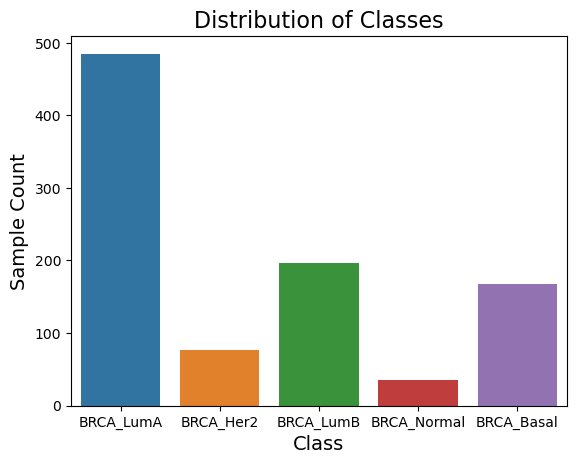

In [6]:
# Assuming 'subtype' is the column with your labels
sns.countplot(data=MoGCN_all_omic, x='Subtype')  # Adjust 'subtype' if your label column has a different name
plt.title("Distribution of Classes", fontsize=16)
plt.xlabel('Class', fontsize=14)
plt.ylabel('Sample Count', fontsize=14)
plt.show()

In [9]:
# Step 1: Read the original data files
MoGCN_Transcriptomics = pd.read_csv("MoGCN_Transcriptome_Scaled_Matrix.csv", index_col=0)

# Check the dimensions of the dataframes
print("MoGCN_Transcriptomics shape:", MoGCN_Transcriptomics.shape)

MoGCN_Transcriptomics shape: (960, 101)


In [10]:
MoGCN_Transcriptomics.head()

,C3orf72,AMAC1L3,BSND,FOXL2,ID2B,SFTPB,WNT3A,PPIAL4C,KRT13,OR10AD1,...,PEG10,PIWIL2,C9orf153,CT62,TAL2,FGF18,TRIM72,LMO1,CXCL13,Subtype
Sample.ID,,,,,,,,,,,,,,,,,,,,,
TCGA.3C.AAAU.01,-0.168512,0.471931,1.058565e+00,-0.243386,-0.457639,-0.144653,-0.206339,-0.804669,-0.125015,3.426232,...,-0.716467,-0.114263,-0.216422,1.638272,-0.548003,-0.308732,-0.109925,3.082493e-01,-0.172668,BRCA_LumA
TCGA.3C.AALI.01,0.077053,0.579377,-1.881204e-01,0.217520,-0.385345,-0.159403,-0.220763,0.075110,-0.124694,1.310156,...,3.135852,-0.080411,-0.863000,-1.103470,-0.664480,-0.279318,-0.103895,6.860000e-16,-0.096331,BRCA_Her2
TCGA.3C.AALJ.01,-0.192964,0.216069,-1.870000e-16,-0.140927,-0.073912,-0.159403,-0.144891,-0.415992,-0.010926,3.210579,...,-0.640813,-0.039596,-0.012590,1.339657,1.633512,-0.333404,-0.111211,6.860000e-16,-0.118069,BRCA_LumB
TCGA.3C.AALK.01,-0.075569,-0.773841,-1.870000e-16,-0.079730,-0.378593,-0.135796,-0.099573,-0.512206,-0.125015,-0.996172,...,-0.694838,-0.189132,-0.086788,1.101107,0.803691,0.920200,-0.116187,-2.940058e-01,-0.165824,BRCA_LumA
TCGA.4H.AAAK.01,-0.069762,0.000000,-1.870000e-16,-0.053527,-0.364153,-0.047461,-0.084215,-0.532362,0.011434,-0.980722,...,-0.248780,-0.026267,0.200876,-0.342676,0.009653,3.845881,-0.024134,-2.936552e-01,-0.088519,BRCA_LumA


In [11]:
MoGCN_Transcriptomics.describe()

,C3orf72,AMAC1L3,BSND,FOXL2,ID2B,SFTPB,WNT3A,PPIAL4C,KRT13,OR10AD1,...,RPGRIP1,PEG10,PIWIL2,C9orf153,CT62,TAL2,FGF18,TRIM72,LMO1,CXCL13
count,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,...,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02
mean,-1.145835e-11,4.166664e-12,-4.062509e-11,6.249997e-12,5.208337e-12,1.770834e-11,-1.145833e-11,-1.458333e-11,-4.375000e-11,-4.166092e-12,...,3.125000e-12,6.250012e-12,2.083334e-12,9.375001e-12,8.333334e-12,-1.875000e-11,7.291667e-12,-4.895834e-11,-1.041645e-11,-8.333334e-12
std,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,...,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00
min,-4.144863e-01,-1.203022e+00,-2.242267e-01,-4.475461e-01,-1.207528e+00,-2.095011e-01,-5.349715e-01,-1.700867e+00,-1.783031e-01,-1.293924e+00,...,-1.196754e+00,-7.164671e-01,-2.695874e-01,-9.985346e-01,-1.103470e+00,-6.644805e-01,-9.674443e-01,-1.524772e-01,-3.000683e-01,-3.345305e-01
25%,-1.789538e-01,-4.865982e-01,-1.715621e-01,-1.992506e-01,-5.700566e-01,-1.610522e-01,-2.295332e-01,-6.519936e-01,-1.193145e-01,-6.363896e-01,...,-6.095709e-01,-5.028060e-01,-2.064747e-01,-6.489262e-01,-6.398556e-01,-3.893969e-01,-5.628563e-01,-1.177416e-01,-2.817227e-01,-1.772533e-01
50%,-1.434953e-01,0.000000e+00,-1.870000e-16,-1.624334e-01,-2.566041e-01,-1.466849e-01,-1.970925e-01,-2.020803e-01,-9.159961e-02,1.450000e-15,...,-2.573093e-01,-4.030425e-01,-1.652836e-01,-2.561260e-01,-2.742897e-01,-2.780501e-01,-2.892810e-01,-1.051715e-01,-2.012090e-01,-1.528112e-01
75%,-8.591281e-02,0.000000e+00,-1.870000e-16,-9.818016e-02,2.524092e-01,-1.163410e-01,-1.180857e-01,4.394013e-01,-7.052841e-02,1.450000e-15,...,3.117449e-01,3.415780e-02,-9.568973e-02,3.304231e-01,2.689677e-01,-4.045303e-02,1.721476e-01,-8.057647e-02,6.860000e-16,-9.760353e-02
max,1.899354e+01,1.330119e+01,2.978913e+01,1.438517e+01,1.251332e+01,1.600460e+01,1.516145e+01,7.470205e+00,2.795142e+01,5.808635e+00,...,7.859712e+00,9.052168e+00,1.821486e+01,7.797758e+00,1.372477e+01,1.604633e+01,1.035060e+01,2.380179e+01,1.799725e+01,2.180586e+01


In [12]:
MoGCN_Transcriptomics.dtypes.value_counts()

float64    100
object       1
Name: count, dtype: int64

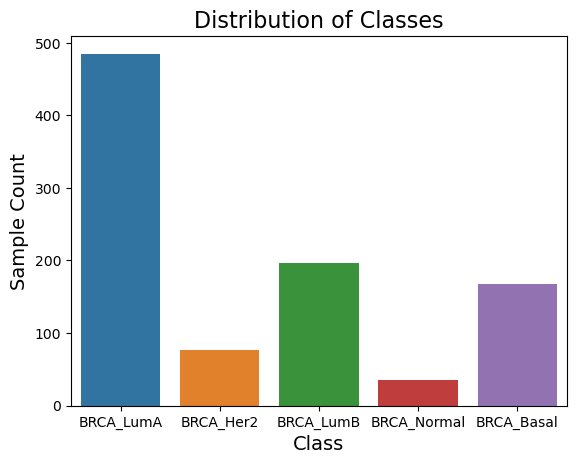

In [13]:
# Assuming 'subtype' is the column with your labels
sns.countplot(data=MoGCN_Transcriptomics, x='Subtype')  # Adjust 'subtype' if your label column has a different name
plt.title("Distribution of Classes", fontsize=16)
plt.xlabel('Class', fontsize=14)
plt.ylabel('Sample Count', fontsize=14)
plt.show()

In [14]:
# Step 1: Read the original data files
MoGCN_epigenomics = pd.read_csv("MoGCN_Epignome_Scaled_Matrix.csv", index_col=0)

# Check the dimensions of the dataframes
print("MoGCN_epigenomics shape:", MoGCN_epigenomics.shape)

MoGCN_epigenomics shape: (960, 101)


In [15]:
MoGCN_epigenomics.head()

,cg23365832,cg08085165,cg05852416,cg08222185,cg06538003,cg00156216,cg00176879,cg00537910,cg09253125,cg14992108,...,cg04469303,cg16928795,cg00954566,cg17952262,cg24476569,cg11953868,cg09215553,cg07550362,cg15827031,Subtype
Sample.ID,,,,,,,,,,,,,,,,,,,,,
TCGA.3C.AAAU.01,0.040411,0.391647,0.968440,-0.190546,0.025419,-0.212035,0.941135,0.740475,-0.315292,-0.243719,...,-0.321320,1.325220,0.308616,-0.887066,-0.773193,1.467397,0.160536,-1.420219,-1.591537,BRCA_LumA
TCGA.3C.AALI.01,-0.072686,-1.806990,-0.042702,-0.415126,0.134498,0.209216,-1.711174,0.276920,-0.682428,0.135496,...,0.342149,-0.130937,-0.031225,0.617328,-0.401255,-1.328891,0.022099,-1.125542,2.595897,BRCA_Her2
TCGA.3C.AALJ.01,0.058615,0.536090,-0.288617,1.430800,0.328260,-0.200017,0.509003,-0.493607,0.854754,0.032594,...,0.188897,-1.092862,-0.107396,-0.600972,-0.683069,-0.592264,-0.048177,1.595070,-1.469253,BRCA_LumB
TCGA.3C.AALK.01,0.011323,0.539712,-0.188776,-0.012465,-0.147326,0.025164,0.739600,-0.205762,0.092864,0.196435,...,-0.191752,0.144754,-0.177629,0.485774,1.656554,0.578527,-0.082657,0.941019,0.668172,BRCA_LumA
TCGA.4H.AAAK.01,-0.004847,0.021254,0.137472,0.160000,0.109466,-0.031551,0.036445,-0.010052,-0.064744,0.013446,...,0.023215,0.084028,-0.021353,0.026365,0.020870,0.269078,0.033095,0.171608,-0.025192,BRCA_LumA


In [16]:
MoGCN_epigenomics.describe()

,cg23365832,cg08085165,cg05852416,cg08222185,cg06538003,cg00156216,cg00176879,cg00537910,cg09253125,cg14992108,...,cg07498421,cg04469303,cg16928795,cg00954566,cg17952262,cg24476569,cg11953868,cg09215553,cg07550362,cg15827031
count,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,...,9.600000e+02,960.000000,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02
mean,2.395834e-11,-1.145833e-11,1.562500e-11,3.125008e-12,-1.145833e-11,-9.374994e-12,4.166672e-12,4.166669e-12,1.145833e-11,6.249997e-12,...,-1.770834e-11,0.000000,-3.125009e-12,-1.458333e-11,8.326673e-18,1.770833e-11,2.083335e-12,3.645833e-11,5.208335e-12,2.083330e-12
std,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,...,1.000521e+00,1.000521,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00
min,-1.059076e+00,-1.329166e+01,-2.152925e+00,-2.675293e+00,-2.536894e+00,-2.658316e+00,-7.364520e+00,-8.176809e+00,-1.427043e+00,-3.799196e+00,...,-1.768646e+00,-1.748185,-1.691781e+00,-8.532430e-01,-1.835183e+00,-1.574241e+00,-1.328891e+00,-6.730767e+00,-1.648637e+00,-1.591537e+00
25%,-1.015169e-01,-2.545084e-01,-4.370330e-01,-6.073353e-01,-5.322970e-01,-2.458899e-01,-3.932842e-01,-6.140070e-01,-5.610990e-01,-3.818221e-01,...,-6.183275e-01,-0.236887,-4.342488e-01,-3.063785e-01,-7.973499e-01,-8.228513e-01,-5.377494e-01,-1.675055e-01,-8.463659e-01,-5.660052e-01
50%,-1.172528e-02,1.763509e-01,-4.621480e-02,-4.822913e-02,-8.437094e-02,-1.250515e-01,-4.849393e-02,2.864861e-02,-2.207703e-01,2.613366e-01,...,-1.427918e-01,-0.052004,-6.545110e-02,-1.468755e-01,-1.533495e-01,-2.554741e-01,-2.922384e-01,-5.723614e-02,-1.863123e-01,-4.228138e-01
75%,8.130432e-02,5.563093e-01,2.647100e-01,4.961581e-01,3.604795e-01,2.231513e-02,6.056052e-01,6.354858e-01,1.888305e-01,6.974876e-01,...,3.519364e-01,0.135187,2.413409e-01,9.206422e-03,6.598544e-01,7.231301e-01,1.502383e-02,9.628864e-03,6.841605e-01,1.971413e-01
max,3.027503e+01,1.760940e+00,8.969095e+00,9.462462e+00,1.436104e+01,1.398584e+01,2.471550e+00,3.169848e+00,7.204748e+00,1.860190e+00,...,1.120387e+01,28.438962,2.214648e+01,1.418636e+01,2.643281e+00,3.235768e+00,5.640956e+00,1.524980e+01,3.181299e+00,4.997313e+00


In [17]:
MoGCN_epigenomics.dtypes.value_counts()

float64    100
object       1
Name: count, dtype: int64

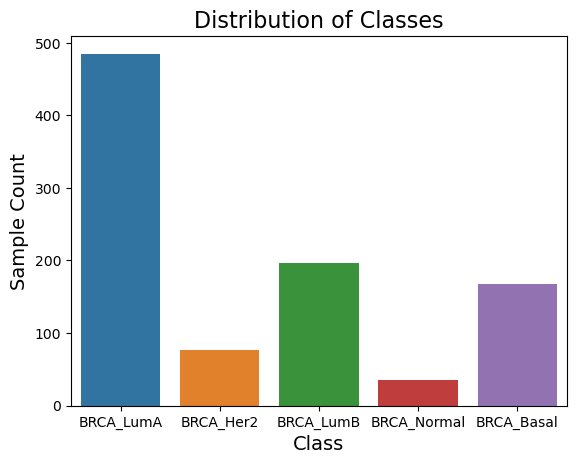

In [18]:
# Assuming 'subtype' is the column with your labels
sns.countplot(data=MoGCN_epigenomics, x='Subtype')  # Adjust 'subtype' if your label column has a different name
plt.title("Distribution of Classes", fontsize=16)
plt.xlabel('Class', fontsize=14)
plt.ylabel('Sample Count', fontsize=14)
plt.show()

In [19]:
# Step 1: Read the original data files
MoGCN_microbiomics = pd.read_csv("MoGCN_Microbiome_Scaled_Matrix.csv", index_col=0)

# Check the dimensions of the dataframes
print("MoGCN_microbiomics shape:", MoGCN_microbiomics.shape)

MoGCN_microbiomics shape: (960, 101)


In [20]:
MoGCN_microbiomics.head()

,Lachnoclostridium,Aeromonas,Chitinivibrio,Luteibacter,Campylobacter,Sunxiuqinia,Terrabacter,Microvirga,Whispovirus,Nitrospira,...,Anaerococcus,Spiribacter,Flavivirus,Hapalosiphon,Roseivirga,Lymphocryptovirus,Elizabethkingia,Enterococcus,Metallosphaera,Subtype
Sample.ID,,,,,,,,,,,,,,,,,,,,,
TCGA.3C.AAAU.01,0.214656,-0.987904,-0.966391,-0.386749,0.239443,-0.436933,-0.855731,-0.365365,0.713628,0.781756,...,-1.392567,-0.736399,-0.087960,-0.081974,-0.847795,0.356845,0.672431,-0.960977,0.746006,BRCA_LumA
TCGA.3C.AALI.01,0.268543,-1.179234,-0.741088,0.211891,0.251850,0.221277,-0.647660,0.104544,0.789639,0.215961,...,-1.199387,-0.486200,-0.124903,0.252259,-0.584197,0.759762,-0.039778,-1.157616,-0.162331,BRCA_Her2
TCGA.3C.AALJ.01,0.389200,-0.408678,-0.607142,-1.317967,-1.064006,-0.030788,-0.771849,0.571098,-0.449859,-0.078719,...,0.140287,1.279795,-0.455626,0.469067,1.281308,1.026604,-1.502974,-2.081642,-2.580340,BRCA_LumB
TCGA.3C.AALK.01,-0.751963,0.562102,-0.131065,-0.714848,-0.047984,1.314678,0.076802,-0.279940,0.601313,-0.139476,...,-1.547187,-0.899822,0.321836,-0.273875,-1.018257,0.139334,0.761147,-1.487278,0.821281,BRCA_LumA
TCGA.4H.AAAK.01,0.293373,0.536013,-1.021502,0.490394,0.385597,0.244589,0.980119,1.568643,1.443863,1.406444,...,-0.772876,-0.533110,-0.552585,-0.087241,-0.401390,-0.090225,2.002849,1.257473,1.202950,BRCA_LumA


In [21]:
MoGCN_microbiomics.describe()

,Lachnoclostridium,Aeromonas,Chitinivibrio,Luteibacter,Campylobacter,Sunxiuqinia,Terrabacter,Microvirga,Whispovirus,Nitrospira,...,Ranavirus,Anaerococcus,Spiribacter,Flavivirus,Hapalosiphon,Roseivirga,Lymphocryptovirus,Elizabethkingia,Enterococcus,Metallosphaera
count,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,...,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02,9.600000e+02
mean,-5.208341e-12,-2.083326e-12,-3.125001e-11,-2.187499e-11,-4.166672e-12,1.666667e-11,7.291678e-12,-9.374999e-12,-1.480297e-17,5.208334e-12,...,2.083330e-12,-1.110223e-17,2.604167e-11,1.041673e-12,-4.166667e-12,-2.083330e-12,7.291641e-12,-3.124997e-12,6.249993e-12,-7.291656e-12
std,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,...,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00,1.000521e+00
min,-4.325014e+00,-3.333401e+00,-2.515318e+00,-7.032491e+00,-4.265227e+00,-7.105435e+00,-3.542450e+00,-3.579379e+00,-5.884845e+00,-2.787659e+00,...,-1.966708e+00,-2.325886e+00,-1.765978e+00,-7.392520e+00,-2.156631e+00,-2.324525e+00,-2.438333e+00,-5.898250e+00,-8.399421e+00,-4.882680e+00
25%,-5.891142e-01,-6.711924e-01,-7.171758e-01,-5.204963e-01,-5.268824e-01,-5.304186e-01,-6.565684e-01,-5.823683e-01,-5.514156e-01,-6.720083e-01,...,-7.228387e-01,-6.685177e-01,-8.762030e-01,-5.154327e-01,-7.163311e-01,-8.244409e-01,-6.096814e-01,-5.995321e-01,-5.337854e-01,-5.199526e-01
50%,2.828083e-02,-3.088854e-02,2.340778e-02,-2.729043e-02,1.172591e-01,5.753816e-02,-2.394540e-02,-7.561727e-03,8.870594e-02,-2.814799e-02,...,-3.949214e-01,-3.740980e-02,-9.145897e-02,1.462215e-01,-2.835788e-01,1.558998e-02,-2.877975e-02,1.662684e-02,1.128176e-02,1.615800e-01
75%,6.819171e-01,6.074764e-01,7.352553e-01,4.579124e-01,6.843599e-01,6.480581e-01,6.290168e-01,5.714945e-01,6.418850e-01,6.880148e-01,...,8.380460e-01,6.449767e-01,7.804330e-01,6.630931e-01,6.097161e-01,7.871744e-01,3.958729e-01,5.688862e-01,5.420718e-01,6.857762e-01
max,2.792746e+00,4.250366e+00,2.707094e+00,6.615472e+00,2.156424e+00,3.118820e+00,3.707658e+00,3.956280e+00,3.440119e+00,3.089651e+00,...,3.913427e+00,3.791961e+00,2.989392e+00,2.571091e+00,4.171392e+00,2.925928e+00,6.218827e+00,6.783785e+00,4.672465e+00,2.122374e+00


In [22]:
MoGCN_microbiomics.dtypes.value_counts()

float64    100
object       1
Name: count, dtype: int64

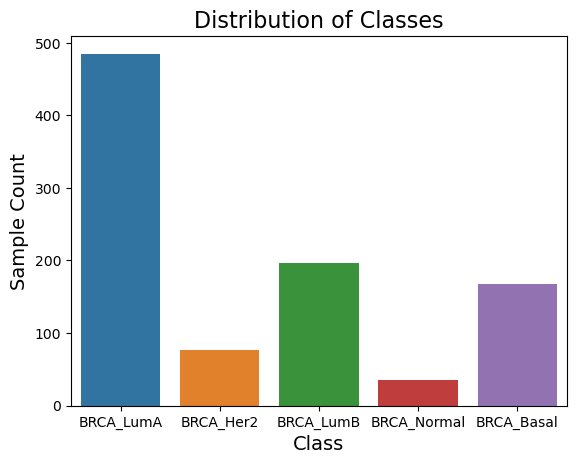

In [23]:
# Assuming 'subtype' is the column with your labels
sns.countplot(data=MoGCN_microbiomics, x='Subtype')  # Adjust 'subtype' if your label column has a different name
plt.title("Distribution of Classes", fontsize=16)
plt.xlabel('Class', fontsize=14)
plt.ylabel('Sample Count', fontsize=14)
plt.show()

In [24]:
def prepare_data(data):
    x = data.drop('Subtype', axis=1)
    y = data['Subtype']
    X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
    return X_train, X_test, y_train, y_test


In [25]:
# Define classifiers with hyperparameters
classifiers = {
    "SVM": SVC(probability=True, C=0.1),
    "Logistic Regression": LogisticRegression(max_iter=10000, C=0.01),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, max_depth=5),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5)
}

In [26]:
# Model evaluation function
def evaluate_models(X_train, X_test, y_train, y_test, classifiers):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    metrics_data = {key: {'Accuracy_train': [], 'F1_train': [], 'AUROC_train': [], 'MCC_train': [],
                          'Accuracy_test': [], 'F1_test': [], 'AUROC_test': [], 'MCC_test': []}
                    for key in classifiers.keys()}
    confusion_matrices = {name: np.zeros((len(np.unique(y_train)), len(np.unique(y_train)))) for name in classifiers}
    feature_importances = {}

    for name, clf in classifiers.items():
        for train_index, test_index in cv.split(X_train, y_train):
            x_train, x_test = X_train.iloc[train_index], X_train.iloc[test_index]
            y_train_fold, y_test_fold = y_train.iloc[train_index], y_train.iloc[test_index]

            pip = Pipeline([
                ('standardization', StandardScaler()),
                ('classification', clf)
            ])
            model = pip.fit(x_train, y_train_fold)
            pred_train = model.predict(x_train)
            pred_prob_train = model.predict_proba(x_train)
            pred_test = model.predict(x_test)
            pred_prob_test = model.predict_proba(x_test)

            # Collect metrics
            for kind, pred, pred_prob, true in [('train', pred_train, pred_prob_train, y_train_fold),
                                                ('test', pred_test, pred_prob_test, y_test_fold)]:
                metrics = metrics_data[name]
                metrics[f'Accuracy_{kind}'].append(accuracy_score(true, pred))
                metrics[f'F1_{kind}'].append(f1_score(true, pred, average='weighted'))
                metrics[f'AUROC_{kind}'].append(roc_auc_score(true, pred_prob, multi_class='ovo', average='macro'))
                metrics[f'MCC_{kind}'].append(matthews_corrcoef(true, pred))

            # Compute confusion matrix
            confusion_matrices[name] += confusion_matrix(y_test_fold, pred_test)

            # Collect feature importances
            if hasattr(clf, 'feature_importances_'):
                if name not in feature_importances:
                    feature_importances[name] = np.zeros(len(X_train.columns))
                feature_importances[name] += clf.feature_importances_ / cv.get_n_splits()
            elif hasattr(clf, 'coef_'):
                if name not in feature_importances:
                    feature_importances[name] = np.zeros(len(X_train.columns))
                feature_importances[name] += np.abs(clf.coef_[0]) / cv.get_n_splits()

    # Normalize confusion matrices
    for name in confusion_matrices:
        confusion_matrices[name] /= cv.get_n_splits()

    return metrics_data, confusion_matrices, feature_importances


In [27]:
def plot_metrics(metrics_data):
    num_metrics = 8  # Total number of metrics (4 training, 4 testing)
    num_models = len(metrics_data)
    fig, axs = plt.subplots(num_models, num_metrics, figsize=(20, num_models * 5))

    metric_names = ['Accuracy_train', 'F1_train', 'AUROC_train', 'MCC_train',
                    'Accuracy_test', 'F1_test', 'AUROC_test', 'MCC_test']

    for i, (name, metrics) in enumerate(metrics_data.items()):
        for j, metric_name in enumerate(metric_names):
            axs[i, j].bar(range(1, 6), metrics[metric_name], color='skyblue')
            axs[i, j].set_title(f'{name} - {metric_name}')
            axs[i, j].set_xticks(range(1, 6))
            axs[i, j].set_xticklabels(range(1, 6))
            axs[i, j].set_ylim([0, 1])  # Assuming metric values range from 0 to 1

    # Adjusting layout and labels
    for ax, metric in zip(axs[0], metric_names):
        ax.set_xlabel(metric)

    for ax, model_name in zip(axs[:, 0], classifiers.keys()):
        ax.set_ylabel(model_name, rotation=90, size='large')

    plt.tight_layout()
    plt.show()


In [28]:
# Print detailed results
def print_detailed_results(metrics_data):
    rows_list = []
    for name, metrics in metrics_data.items():
        num_folds = len(metrics['Accuracy_test'])  # Assuming all metric lists are of equal length
        for i in range(num_folds):
            row = {
                'Model': name,
                'Fold': i + 1,
                'Accuracy_test': metrics['Accuracy_test'][i],
                'F1_test': metrics['F1_test'][i],
                'AUROC_test': metrics['AUROC_test'][i],
                'MCC_test': metrics['MCC_test'][i]
            }
            rows_list.append(row)
    detailed_results_df = pd.DataFrame(rows_list)
    print(detailed_results_df)


In [29]:
# Plot feature importances
def plot_feature_importances(feature_importances, X_train):
    for name, importances in feature_importances.items():
        plt.figure(figsize=(8, 6))
        importances_series = pd.Series(importances, index=X_train.columns)
        importances_series.nlargest(10).plot.bar()
        plt.title(f"Feature Importances for {name}")
        plt.ylabel("Importance")
        plt.xlabel("Features")
        plt.tight_layout()
        plt.show()


In [30]:
# Display confusion matrices
def display_confusion_matrices(confusion_matrices):
    plt.figure(figsize=(12, 10))
    sns.set(style="whitegrid")
    for i, (name, matrix) in enumerate(confusion_matrices.items(), 1):
        plt.subplot(3, 3, i)  # Adjust subplot layout based on the number of classifiers
        sns.heatmap(matrix, annot=True, fmt=".0f", square=True, cmap="Blues", cbar=False)
        plt.title(name)
        plt.ylabel('Actual label')
        plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

Results for All Omics:


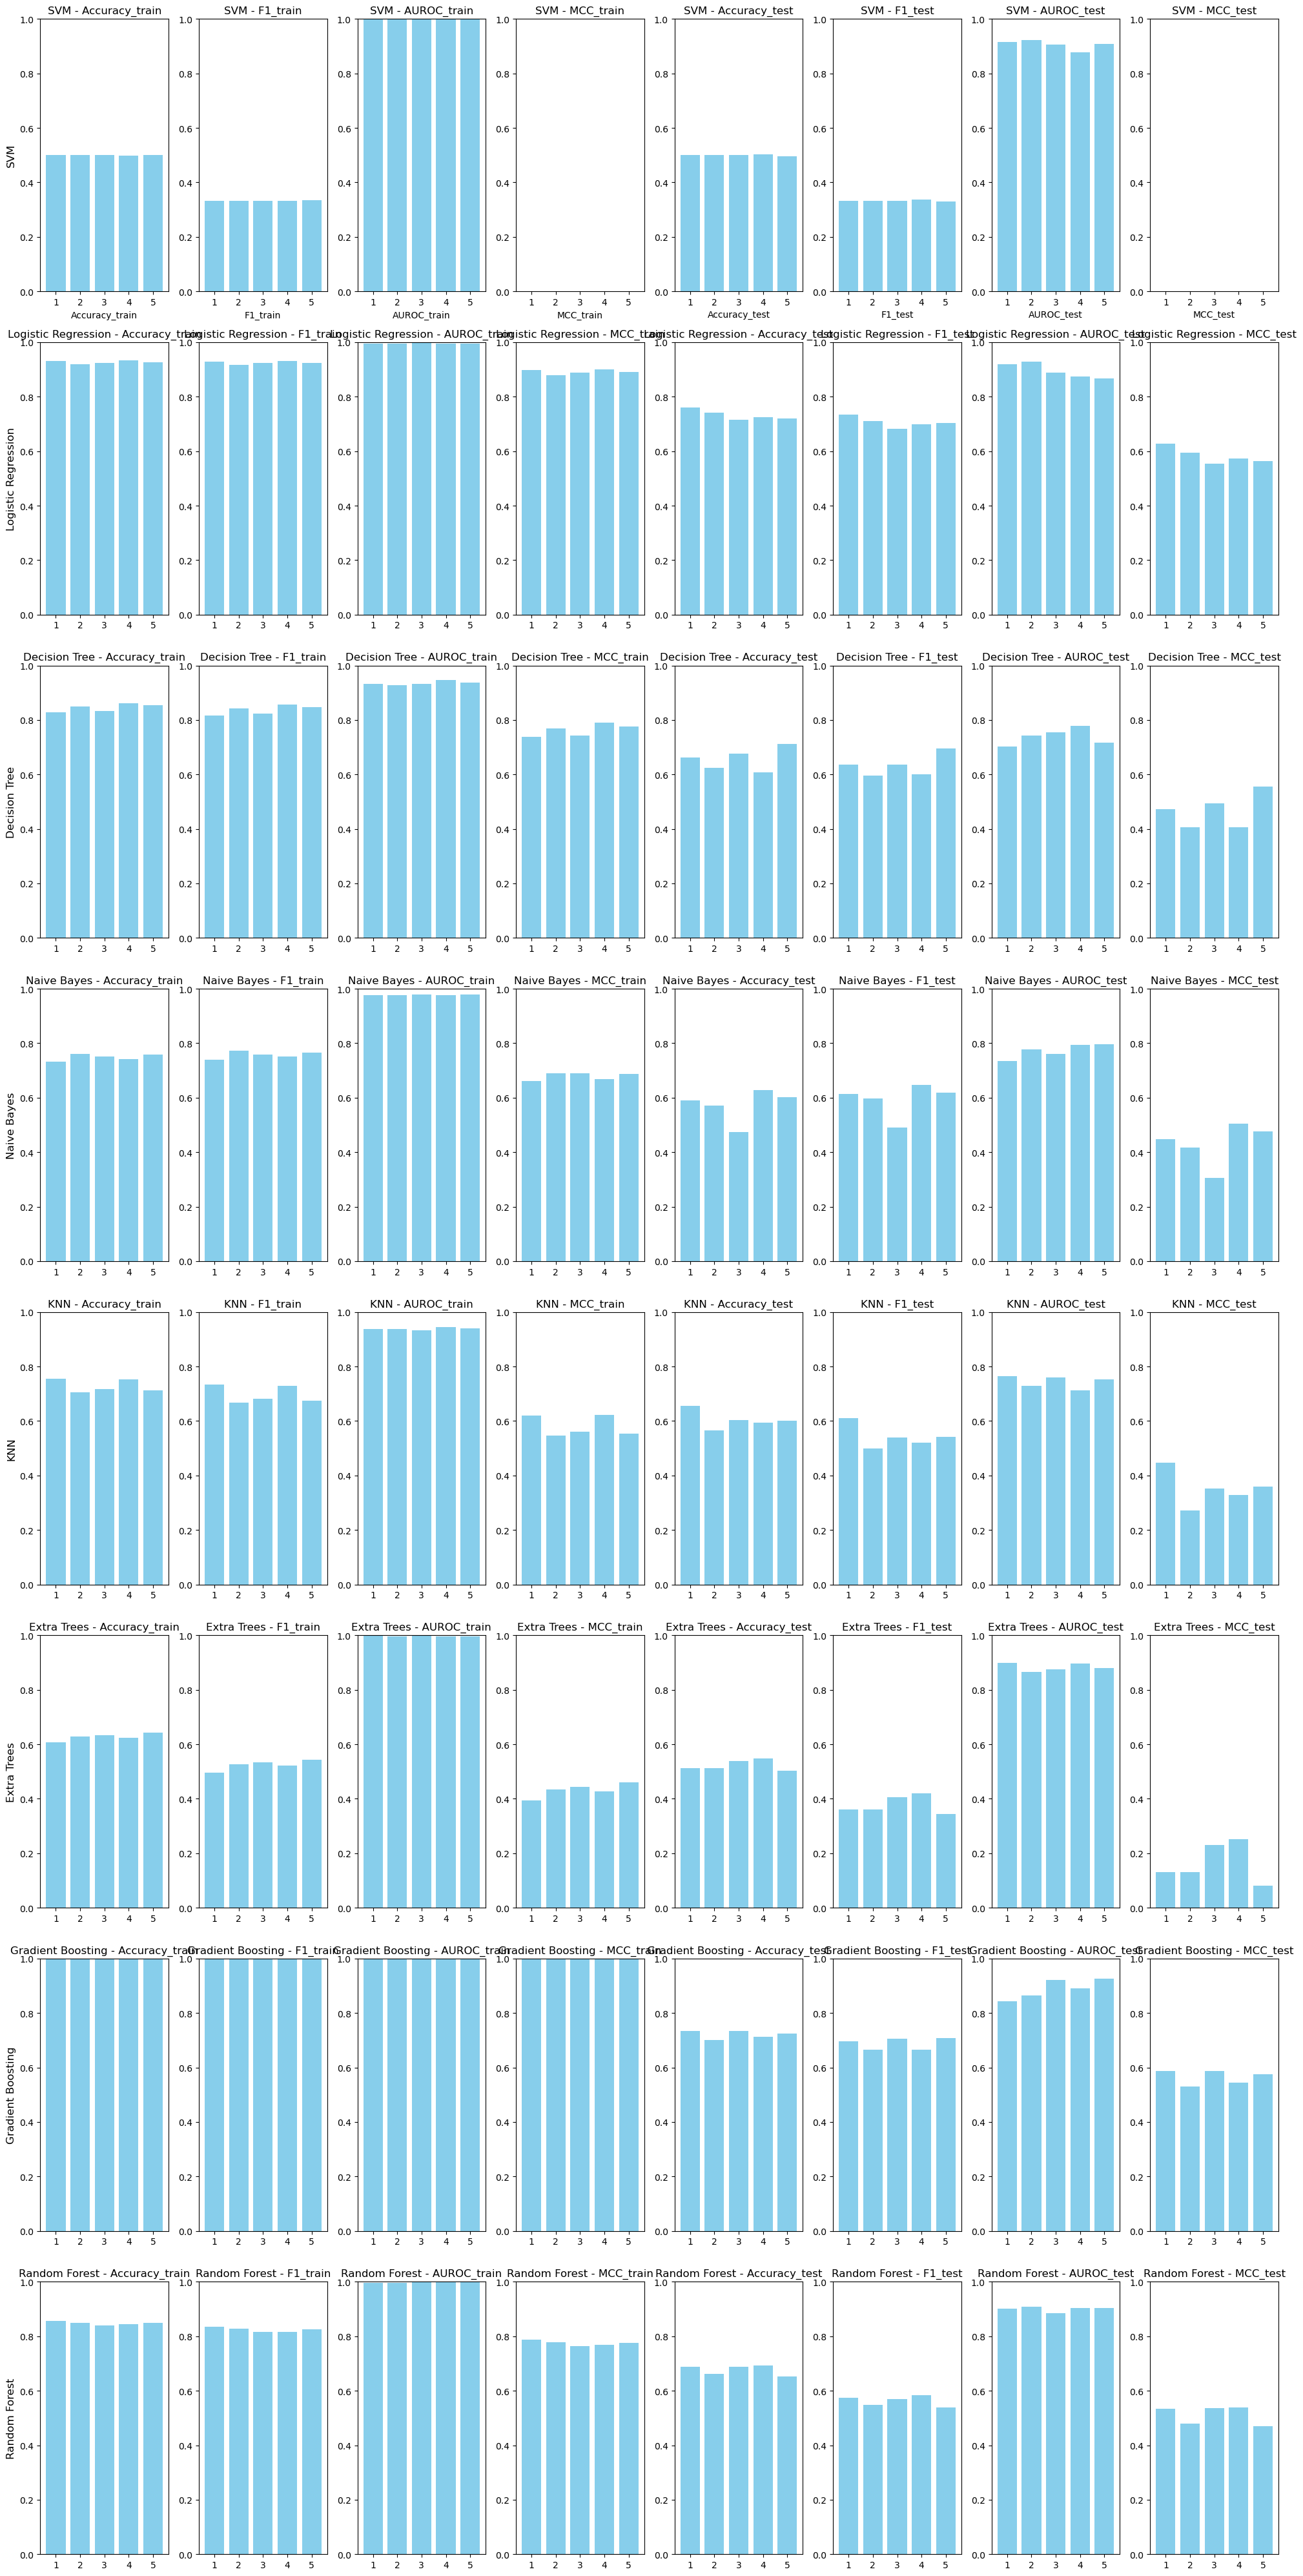

                  Model  Fold  Accuracy_test   F1_test  AUROC_test  MCC_test
0                   SVM     1       0.500000  0.333333    0.915911  0.000000
1                   SVM     2       0.500000  0.333333    0.922359  0.000000
2                   SVM     3       0.500000  0.333333    0.906482  0.000000
3                   SVM     4       0.503268  0.336971    0.876596  0.000000
4                   SVM     5       0.496732  0.329709    0.907487  0.000000
5   Logistic Regression     1       0.759740  0.734416    0.919975  0.626910
6   Logistic Regression     2       0.740260  0.710055    0.929462  0.594944
7   Logistic Regression     3       0.714286  0.683208    0.889277  0.553041
8   Logistic Regression     4       0.725490  0.699145    0.874941  0.572167
9   Logistic Regression     5       0.718954  0.704541    0.866559  0.564043
10        Decision Tree     1       0.662338  0.636749    0.703689  0.472438
11        Decision Tree     2       0.623377  0.595283    0.742385  0.405949

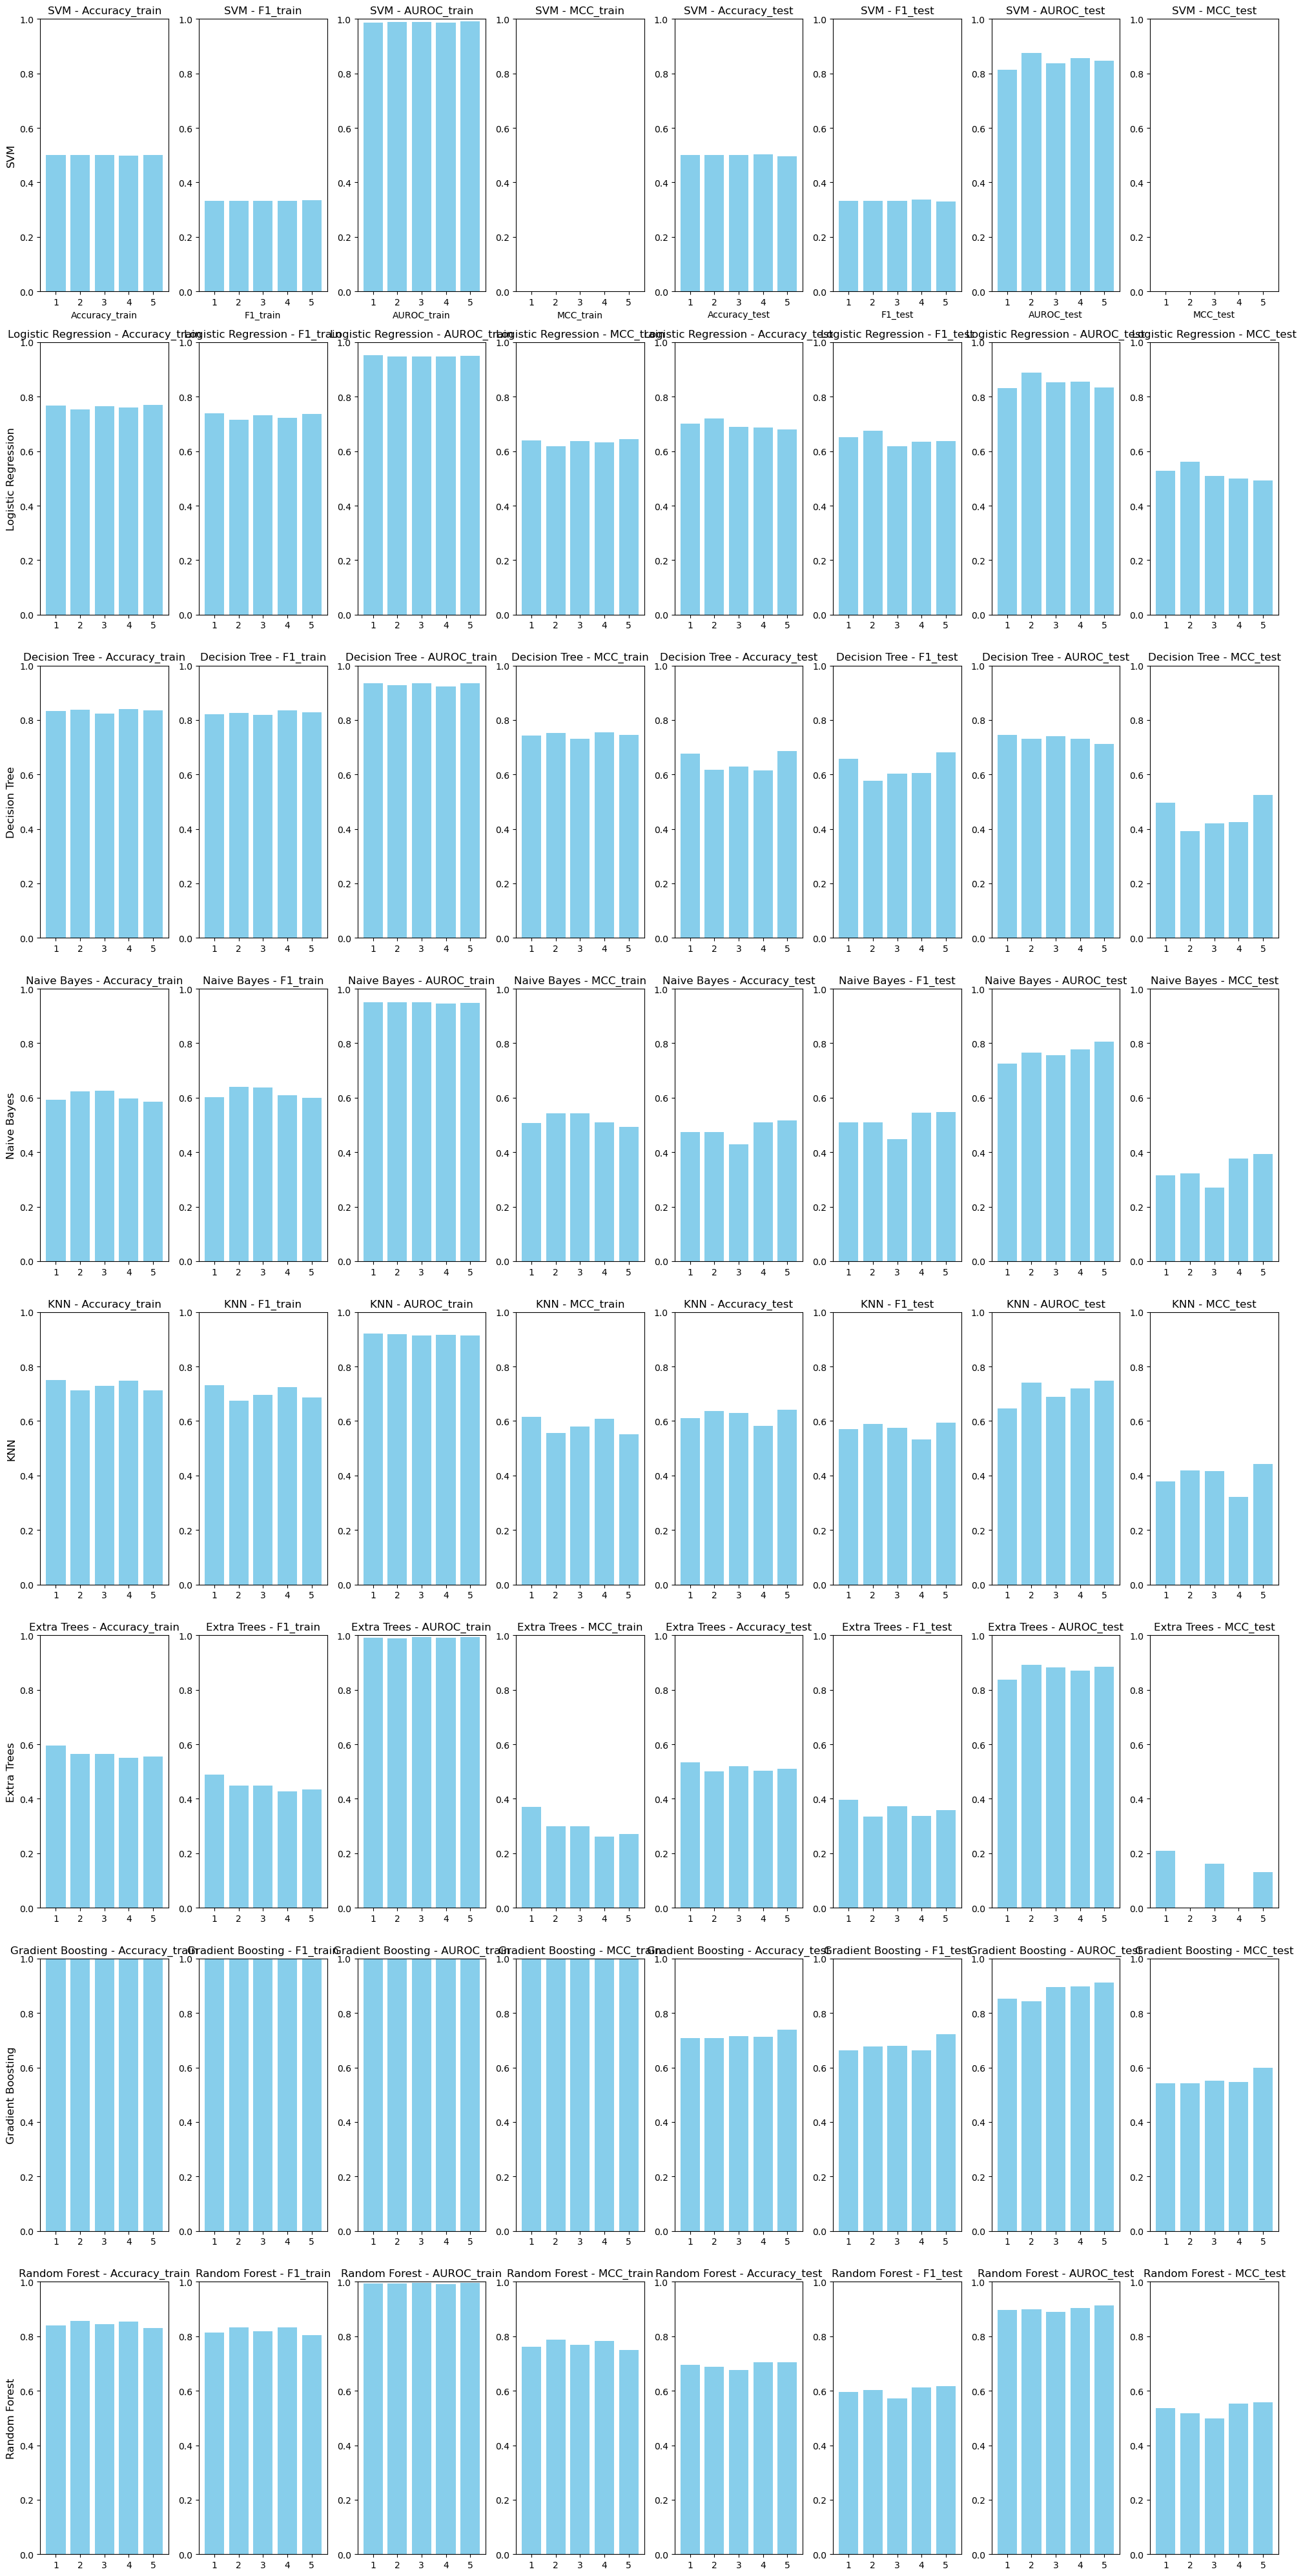

                  Model  Fold  Accuracy_test   F1_test  AUROC_test  MCC_test
0                   SVM     1       0.500000  0.333333    0.813167  0.000000
1                   SVM     2       0.500000  0.333333    0.876250  0.000000
2                   SVM     3       0.500000  0.333333    0.837886  0.000000
3                   SVM     4       0.503268  0.336971    0.855494  0.000000
4                   SVM     5       0.496732  0.329709    0.846086  0.000000
5   Logistic Regression     1       0.701299  0.652211    0.830979  0.528223
6   Logistic Regression     2       0.720779  0.675658    0.888920  0.561017
7   Logistic Regression     3       0.688312  0.618987    0.853593  0.508613
8   Logistic Regression     4       0.686275  0.634875    0.855756  0.498799
9   Logistic Regression     5       0.679739  0.636851    0.833342  0.493217
10        Decision Tree     1       0.675325  0.657934    0.746104  0.496103
11        Decision Tree     2       0.616883  0.577834    0.731117  0.391322

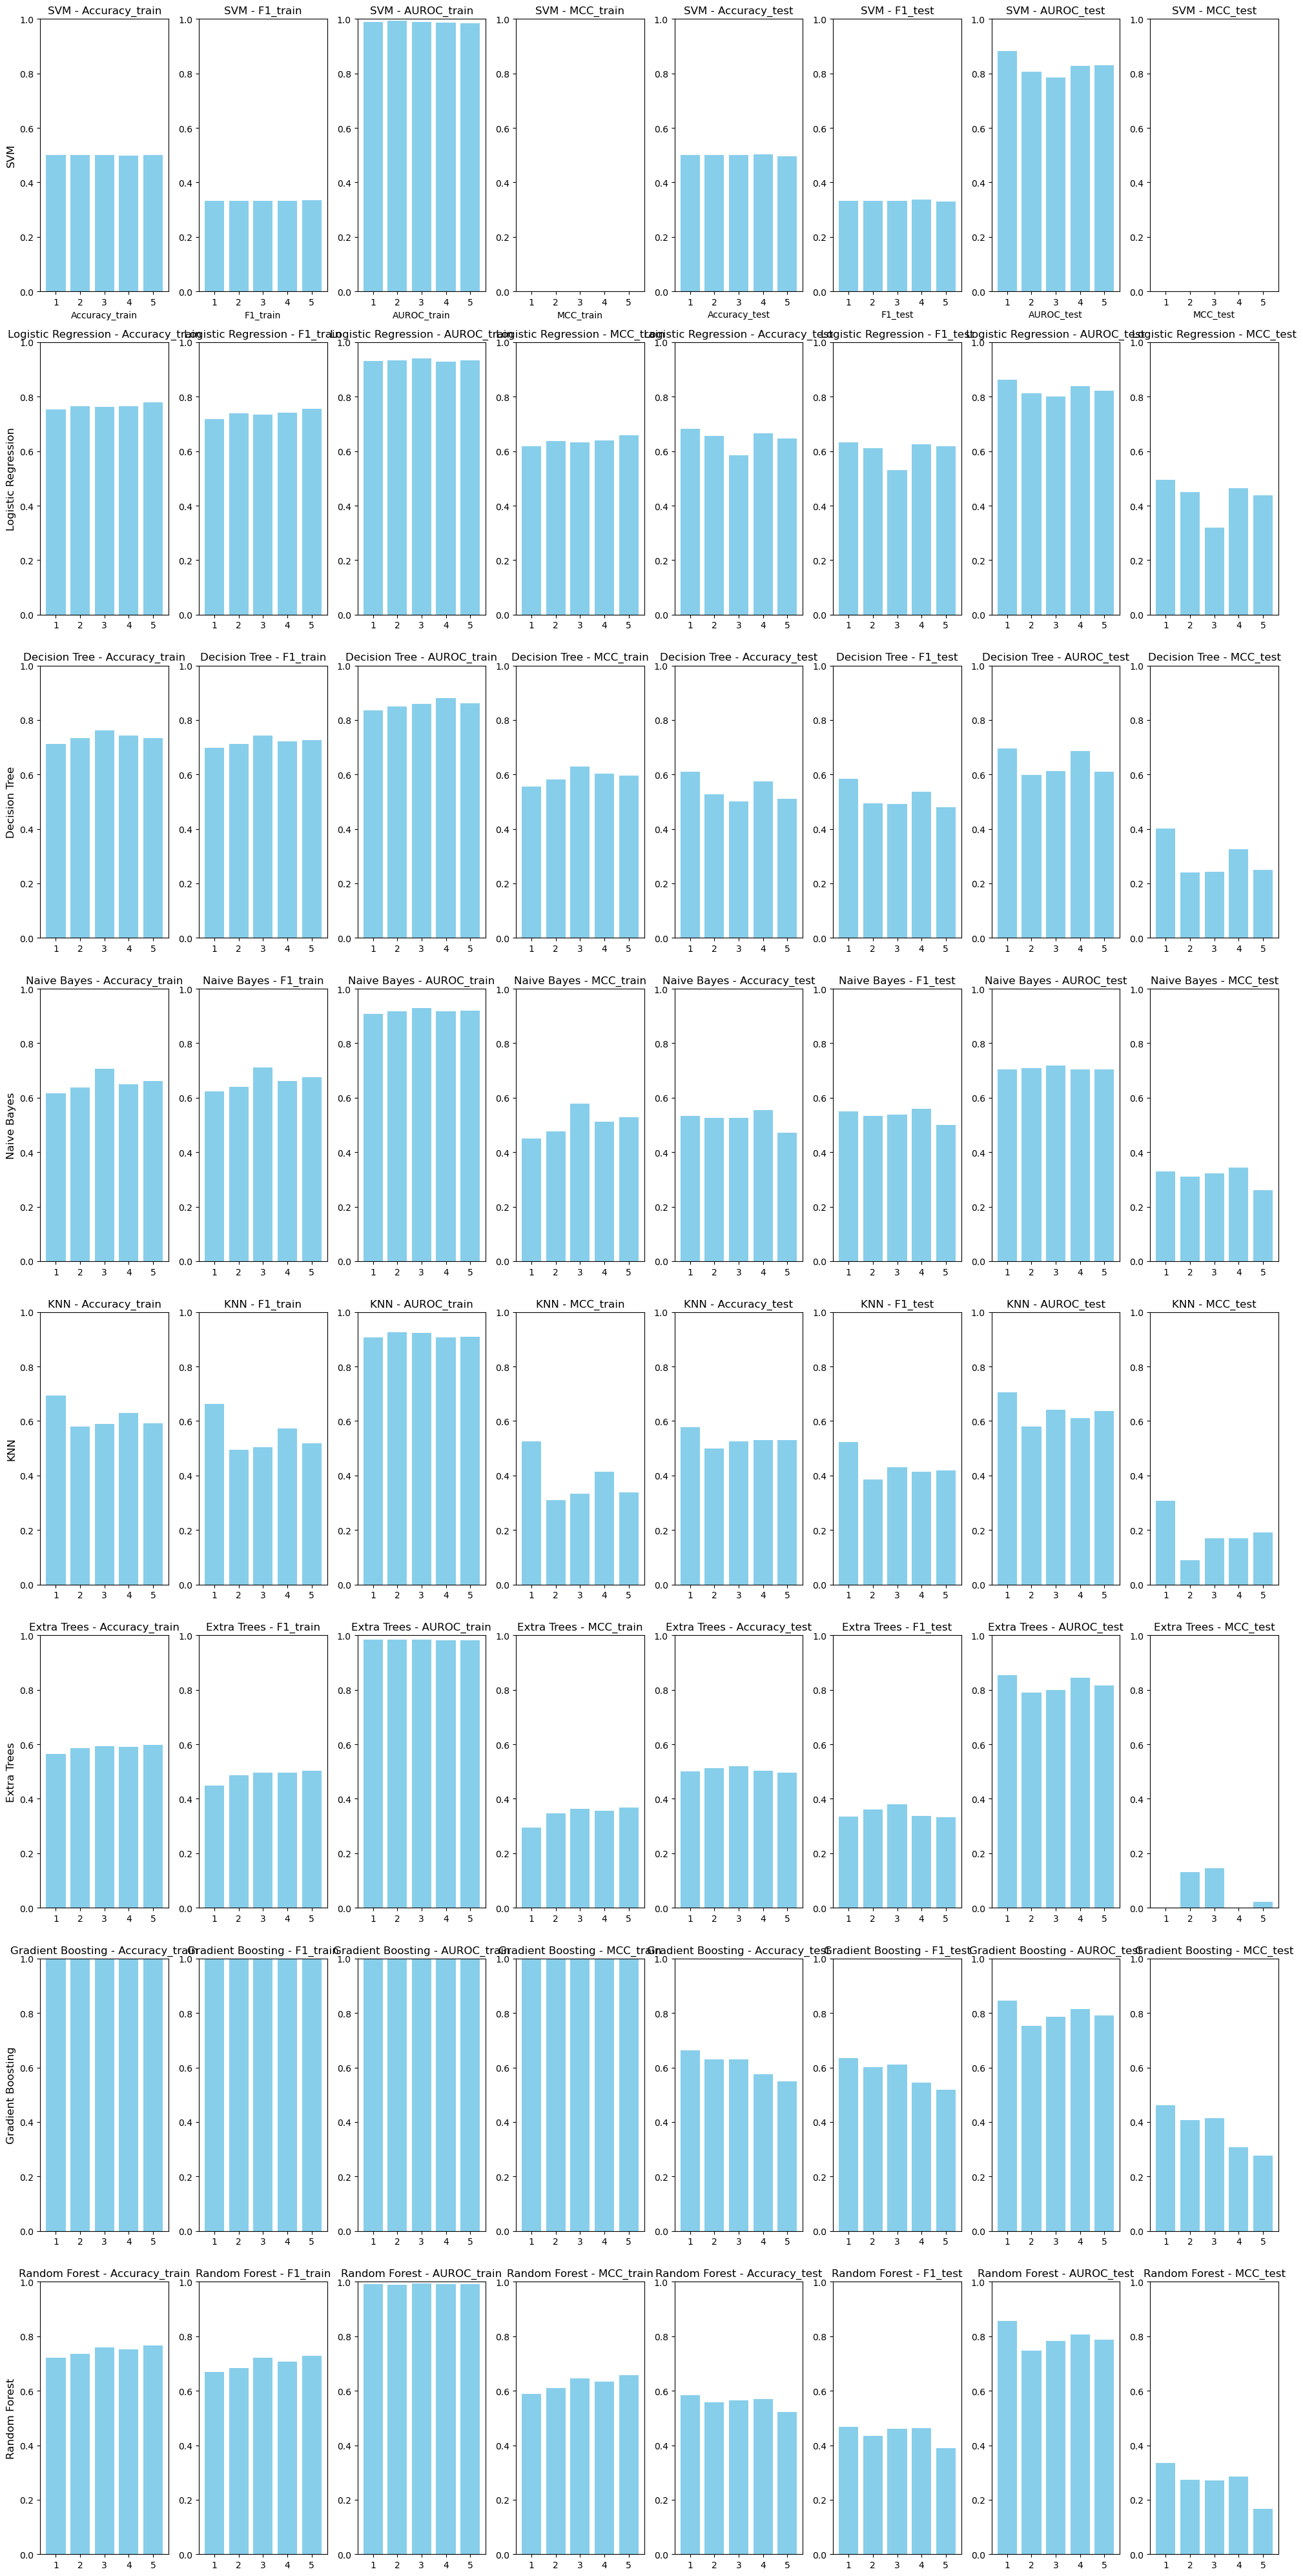

                  Model  Fold  Accuracy_test   F1_test  AUROC_test  MCC_test
0                   SVM     1       0.500000  0.333333    0.881700  0.000000
1                   SVM     2       0.500000  0.333333    0.807427  0.000000
2                   SVM     3       0.500000  0.333333    0.785118  0.000000
3                   SVM     4       0.503268  0.336971    0.828782  0.000000
4                   SVM     5       0.496732  0.329709    0.829577  0.000000
5   Logistic Regression     1       0.681818  0.631824    0.861637  0.495160
6   Logistic Regression     2       0.655844  0.609911    0.812515  0.450397
7   Logistic Regression     3       0.584416  0.529659    0.801563  0.318777
8   Logistic Regression     4       0.666667  0.624356    0.837540  0.465021
9   Logistic Regression     5       0.647059  0.619050    0.822334  0.439128
10        Decision Tree     1       0.610390  0.583562    0.696148  0.400998
11        Decision Tree     2       0.525974  0.493650    0.599149  0.239628

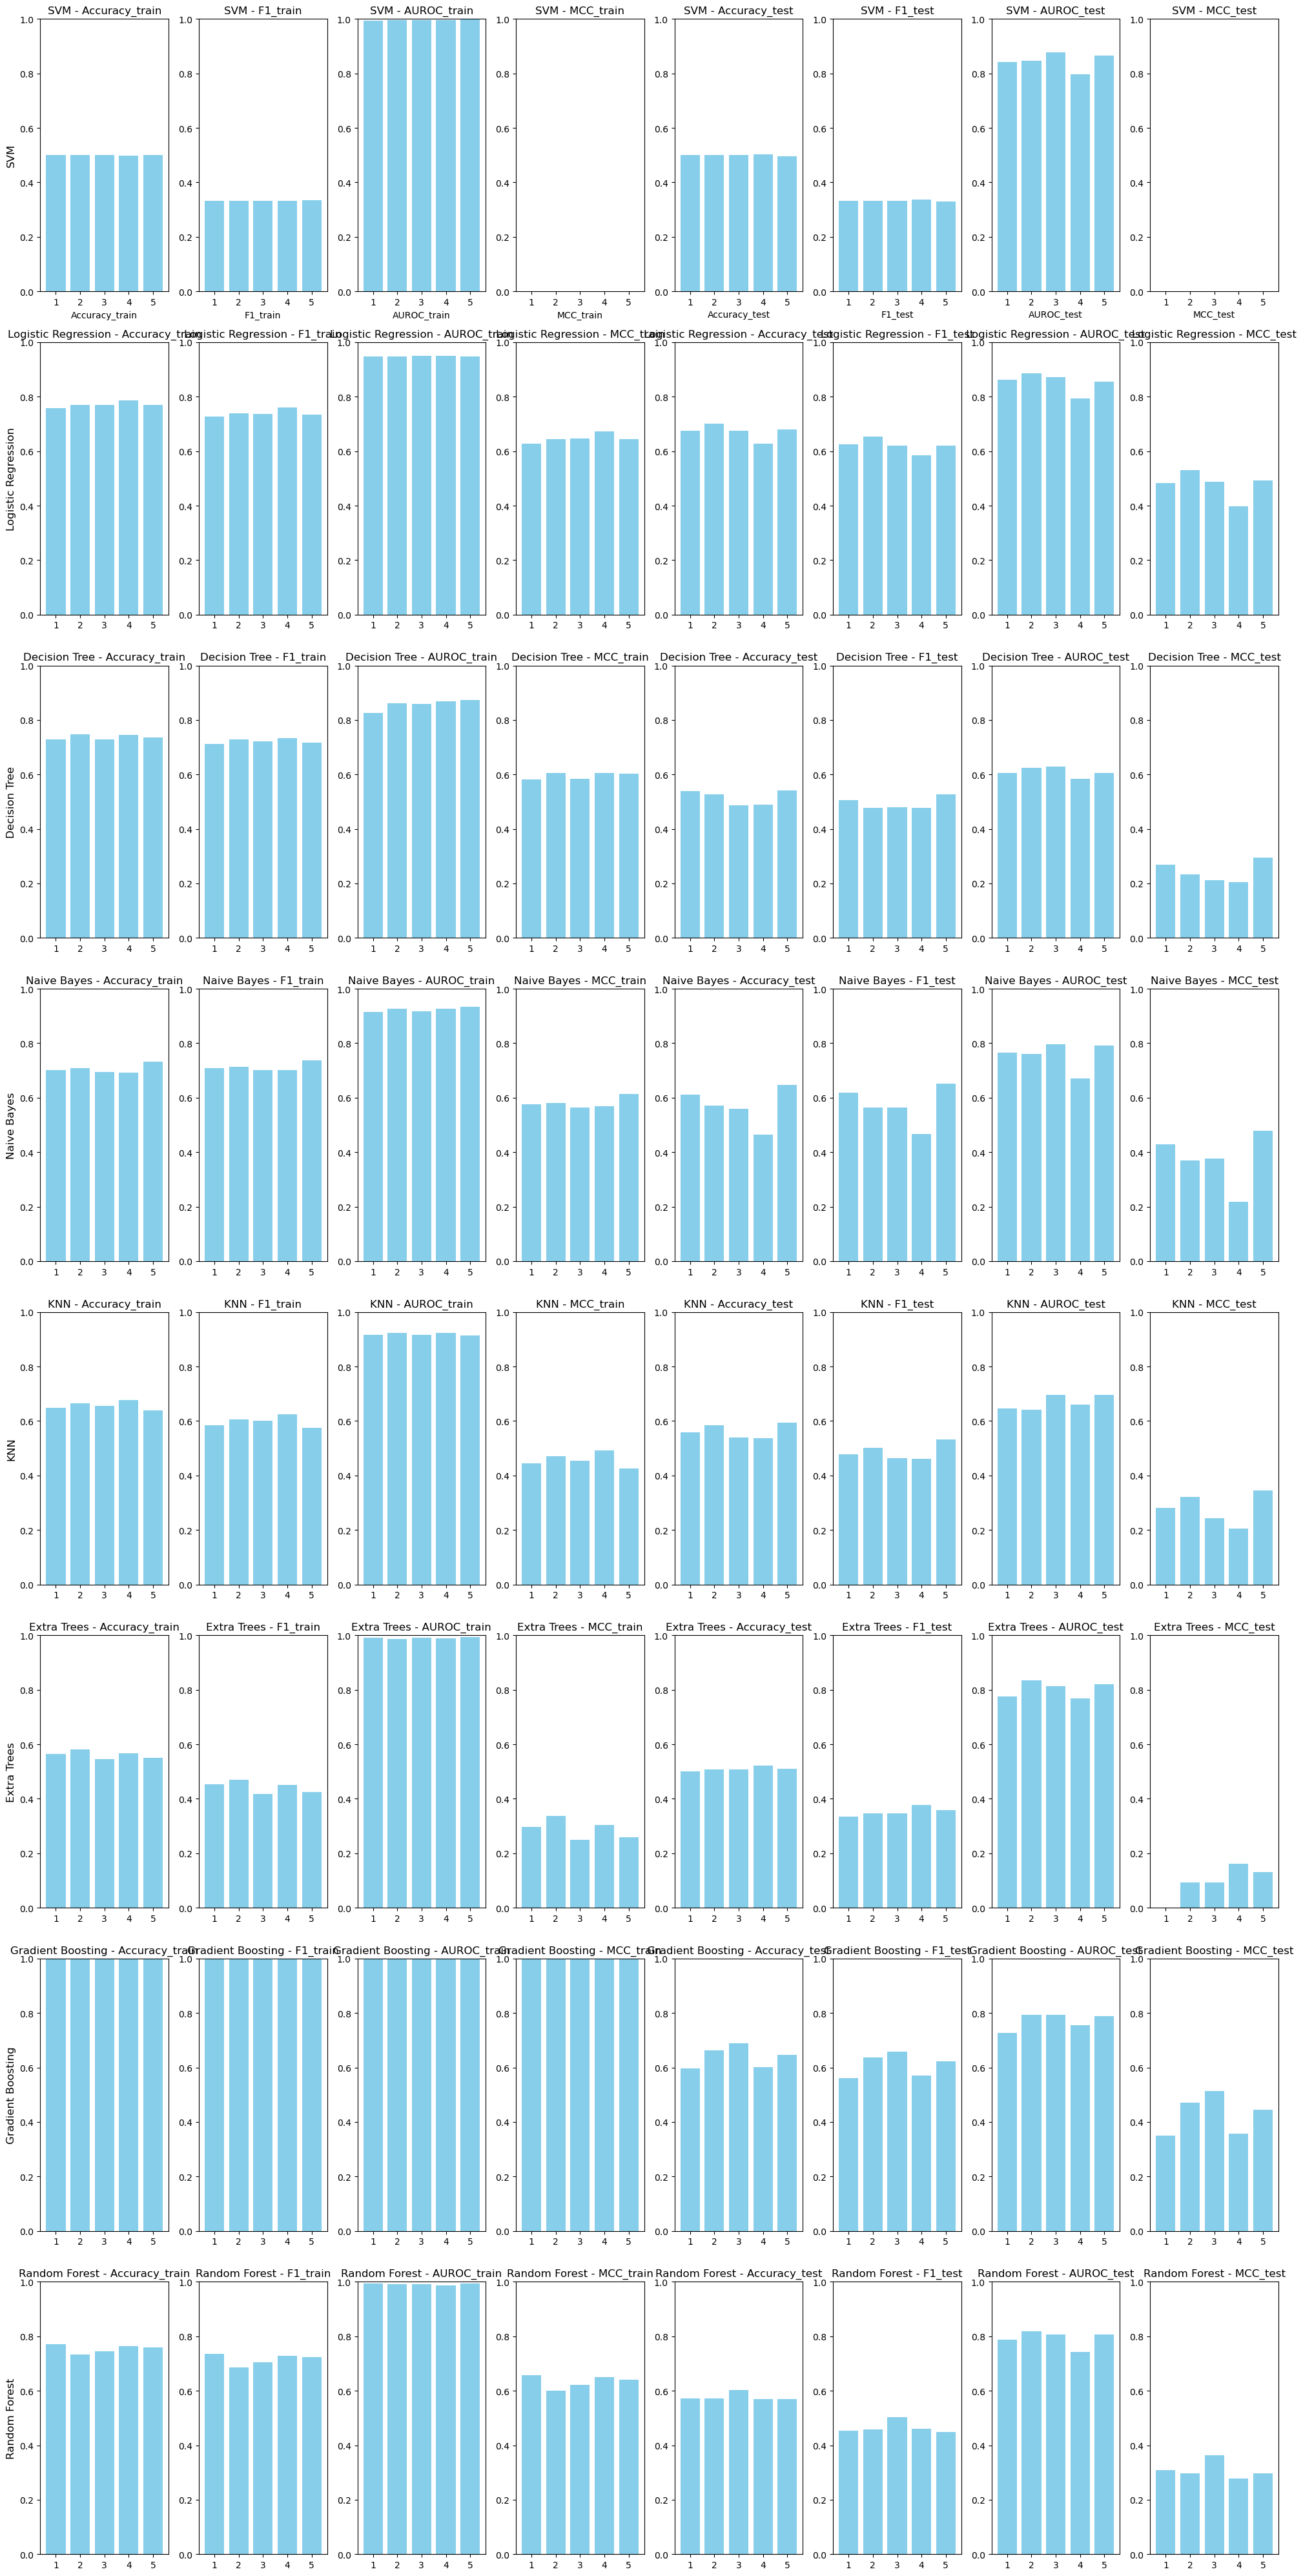

                  Model  Fold  Accuracy_test   F1_test  AUROC_test  MCC_test
0                   SVM     1       0.500000  0.333333    0.843138  0.000000
1                   SVM     2       0.500000  0.333333    0.847441  0.000000
2                   SVM     3       0.500000  0.333333    0.878405  0.000000
3                   SVM     4       0.503268  0.336971    0.796727  0.000000
4                   SVM     5       0.496732  0.329709    0.865100  0.000000
5   Logistic Regression     1       0.675325  0.624385    0.861509  0.483860
6   Logistic Regression     2       0.701299  0.653098    0.886308  0.529865
7   Logistic Regression     3       0.675325  0.621321    0.871370  0.486889
8   Logistic Regression     4       0.627451  0.585364    0.794014  0.397975
9   Logistic Regression     5       0.679739  0.621065    0.854651  0.493627
10        Decision Tree     1       0.538961  0.505987    0.604458  0.269645
11        Decision Tree     2       0.525974  0.477774    0.624440  0.232464

In [31]:
# Process each dataset
datasets = {
    'All Omics': MoGCN_all_omic,
    'Transcriptomics': MoGCN_Transcriptomics,
    'Epigenomics': MoGCN_epigenomics,
    'Microbiomics': MoGCN_microbiomics
}
all_metrics = {}
all_conf_matrices = {}
all_feature_importances = {}
all_X_train = {}

for name, data in datasets.items():
    X_train, X_test, y_train, y_test = prepare_data(data)
    metrics, conf_matrices, feat_importances = evaluate_models(X_train, X_test, y_train, y_test, classifiers)
    
    all_metrics[name] = metrics
    all_conf_matrices[name] = conf_matrices
    all_feature_importances[name] = feat_importances
    all_X_train[name] = X_train

    # Print detailed results
    print(f"Results for {name}:")
    plot_metrics(metrics)
    print_detailed_results(metrics)


In [32]:
# Function to print detailed metrics for each dataset and model
def print_detailed_metrics(all_metrics):
    print("Detailed Metrics Matrix:\n")
    for dataset_name, metrics_data in all_metrics.items():
        print(f"Dataset: {dataset_name}\n")
        for model_name, metrics in metrics_data.items():
            print(f"Model: {model_name}")
            for metric_type, values in metrics.items():
                print(f"  {metric_type}: {np.mean(values):.4f} ± {np.std(values):.4f}")
            print("\n")

# Assuming 'all_metrics' is filled with data from all datasets
print_detailed_metrics(all_metrics)

Detailed Metrics Matrix:

Dataset: All Omics

Model: SVM
  Accuracy_train: 0.5000 ± 0.0005
  F1_train: 0.3333 ± 0.0006
  AUROC_train: 0.9997 ± 0.0002
  MCC_train: 0.0000 ± 0.0000
  Accuracy_test: 0.5000 ± 0.0021
  F1_test: 0.3333 ± 0.0023
  AUROC_test: 0.9058 ± 0.0157
  MCC_test: 0.0000 ± 0.0000


Model: Logistic Regression
  Accuracy_train: 0.9274 ± 0.0047
  F1_train: 0.9246 ± 0.0051
  AUROC_train: 0.9958 ± 0.0005
  MCC_train: 0.8911 ± 0.0074
  Accuracy_test: 0.7317 ± 0.0165
  F1_test: 0.7063 ± 0.0167
  AUROC_test: 0.8960 ± 0.0247
  MCC_test: 0.5822 ± 0.0262


Model: Decision Tree
  Accuracy_train: 0.8450 ± 0.0126
  F1_train: 0.8373 ± 0.0150
  AUROC_train: 0.9353 ± 0.0064
  MCC_train: 0.7631 ± 0.0197
  Accuracy_test: 0.6563 ± 0.0374
  F1_test: 0.6324 ± 0.0355
  AUROC_test: 0.7396 ± 0.0268
  MCC_test: 0.4669 ± 0.0570


Model: Naive Bayes
  Accuracy_train: 0.7490 ± 0.0104
  F1_train: 0.7572 ± 0.0112
  AUROC_train: 0.9781 ± 0.0010
  MCC_train: 0.6789 ± 0.0125
  Accuracy_test: 0.5730 ± 0.